# XGBoost Classifier
XGBoost is designed to capture complex nonlinear relationships between features such as location, competition, and customer trends. It provides strong predictive performance even with limited or noisy data and allows for interpretability through feature importance analysis. This makes it well-suited for generating accurate and actionable predictions of restaurant success while integrating multiple factors into a unified model.

## 1. Load final dataset

In [13]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
from xgboost import XGBClassifier

In [14]:
path3 = '/content/drive/MyDrive/Data Mining/Project/model_dataset.csv'

df = pd.read_csv(path3)

print(df.shape)
print(df.head())

(20000, 40)
                      name          city state postal_code   latitude  \
0              Double Knot  Philadelphia    PA       19107  39.949699   
1    Hên Vietnamese Eatery   Cherry Hill    NJ       08003  39.896071   
2  Gourmet Seafood & Grill      Skippack    PA       19473  40.227668   
3           Clear Sky Cafe    Clearwater    FL       33767  27.981960   
4         Coffee House Too  Philadelphia    PA       19125  39.976728   

   longitude  business_stars  RestaurantsPriceRange2  NoiseLevel  \
0 -75.162185             4.5                     3.0         2.0   
1 -74.949167             4.5                     2.0         2.0   
2 -75.404260             3.5                     2.0         1.0   
3 -82.827297             4.5                     2.0         2.0   
4 -75.123718             4.5                     2.0         2.0   

   parking_options_count  ...  location_cluster  num_categories  \
0                    1.0  ...                11               6   
1     

# 2. Basic Checks

In [15]:
print(df.columns.tolist())
print(df["target"].value_counts(dropna=False))
print(df["target"].value_counts(normalize=True, dropna=False))

['name', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'business_stars', 'RestaurantsPriceRange2', 'NoiseLevel', 'parking_options_count', 'meal_options_count', 'ambience_score', 'music_options_count', 'best_nights_count', 'is_full_service', 'is_bar_style', 'is_family_friendly', 'is_takeout_friendly', 'is_date_spot', 'primary_category', 'hours_open_per_week', 'days_open', 'avg_hours_per_day', 'open_late', 'open_early', 'weekend_hours', 'nearest_dist', 'num_neighbors_1km', 'same_cuisine_neighbors', 'avg_neighbor_rating', 'location_cluster', 'num_categories', 'has_nightlife', 'has_fast_food', 'has_breakfast', 'has_seafood', 'has_asian', 'has_mexican', 'has_italian', 'target']
target
0    13991
1     6009
Name: count, dtype: int64
target
0    0.69955
1    0.30045
Name: proportion, dtype: float64


## 3. Define features and target

In [16]:
y = df["target"].astype(int)
X = df.drop(columns=["target"]).copy()


print("Initial X shape:", X.shape)
print("Initial y shape:", y.shape)

Initial X shape: (20000, 39)
Initial y shape: (20000,)


## 4. Handle missing values

In [17]:
missing_ratio = X.isnull().mean()
high_missing = missing_ratio[missing_ratio > 0.70].index.tolist()

print("Dropping high-missing columns:", high_missing)

X = X.drop(columns=high_missing)

# Fill numeric missing values with median
numeric_cols = X.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

# Fill categorical missing values
categorical_cols = X.select_dtypes(exclude=[np.number]).columns

for col in categorical_cols:
    X[col] = X[col].fillna("Unknown")

# One-hot encode categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Final X shape after encoding:", X.shape)
print("Remaining missing:", X.isnull().sum().sum())

Dropping high-missing columns: []
Final X shape after encoding: (20000, 11815)
Remaining missing: 0


## 5. Train-test split

In [18]:
feature_columns = X.columns.tolist()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=42
)

pos = y_train.sum()
neg = len(y_train) - pos

scale_pos_weight = neg / pos if pos > 0 else 1

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight = neg / pos if pos > 0 else 1

scale_pos_weight: 2.328133125325013


## 6. Train XGBoost

In [19]:
model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=2,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, ...)

## 7. Evaluate model

In [20]:

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.91925
Test ROC-AUC: 0.978318539865057

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      2798
           1       0.83      0.92      0.87      1202

    accuracy                           0.92      4000
   macro avg       0.90      0.92      0.91      4000
weighted avg       0.92      0.92      0.92      4000



## 8. Top features


In [21]:
importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 Features:")
print(importance_df.head(15))


Top 15 Features:
                                     feature  importance
23                    same_cuisine_neighbors    0.099577
2                             business_stars    0.085515
21                              nearest_dist    0.026169
7                             ambience_score    0.019009
3007   name_Founding Farmers King of Prussia    0.018571
6305               name_Pat's King of Steaks    0.018422
9070               name_The Stone House Cafe    0.018340
6                         meal_options_count    0.017443
2599                     name_El Charro Cafe    0.015922
24                       avg_neighbor_rating    0.015256
4                                 NoiseLevel    0.011919
10617                               state_PA    0.011367
5                      parking_options_count    0.010866
9                          best_nights_count    0.009572
11264                      postal_code_85711    0.009143


**Confusion Matrix Plot**

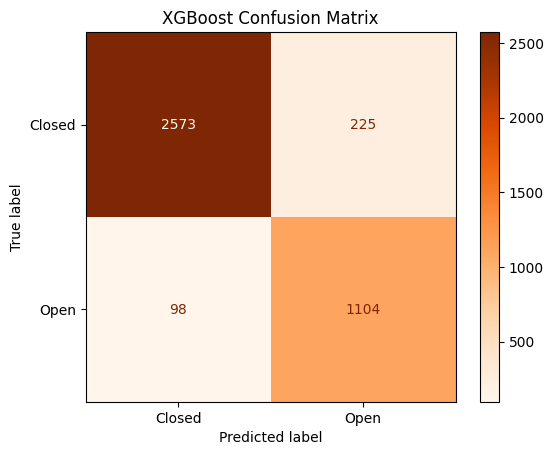

In [22]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Closed", "Open"]
)

disp.plot(cmap="Oranges", values_format="d")
plt.title("XGBoost Confusion Matrix")
plt.grid(False)
plt.show()


**ROC Curve Plot**

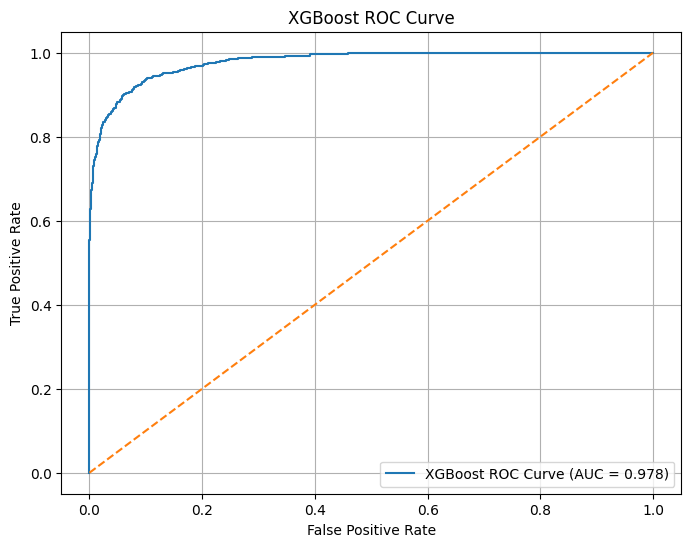

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"XGBoost ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

**Top 15 Feature Importances Plot**

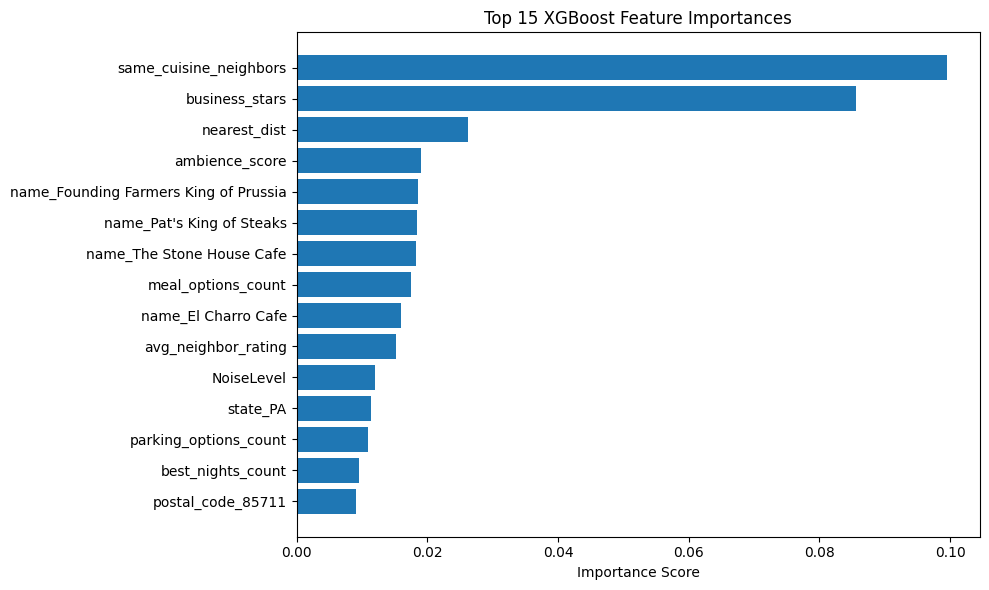

In [25]:
top15 = importance_df.head(15).sort_values(by="importance")

plt.figure(figsize=(10, 6))
plt.barh(top15["feature"], top15["importance"])
plt.xlabel("Importance Score")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

# Save

In [26]:
importance_df.to_csv("xgb_feature_importance.csv", index=False)

joblib.dump(model, "xgb_model.pkl")

import json
with open("xgb_feature_columns.json", "w") as f:
    json.dump(feature_columns, f)